# NB05 — Defense Syndromes (H1b)

**Purpose**: Identify which defense-system pairs co-occur at species level
more (or less) often than expected under a null model that preserves
per-system marginal prevalence within each phylum. Systems that co-occur
beyond null are candidate "defense syndromes" — the ecological signature of
mobile defense-island transfer (Rocha & Bikard 2022).

**Null model** (phylum-stratified column permutation):
- Within each phylum, independently shuffle each system column across species.
- This preserves each system's per-phylum prevalence while breaking co-occurrence.
- Repeat 1,000 permutations to build a null distribution of co-occurrence counts
  per pair.

**Outputs**:
- `data/syndrome_pairs.tsv` — pairwise OR, observed count, null mean, empirical p, BH-FDR q.
- `figures/syndrome_heatmap.png` — signed log10(OR) matrix.
- `figures/syndrome_network.png` — network of significant positive syndromes.

**Analysis set**: 7,323 species (n_genomes ≥ 5, non-null covariates).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

DATA_DIR = "../data"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

RNG = np.random.default_rng(20260715)
N_PERM = 1000

SYSTEMS = ["CRISPR-Cas", "R-M Type I", "R-M Type II", "CBASS", "Gabija", "BREX", "DISARM", "Retron_stringent"]

## 1. Load matrix and filter to analysis set

In [2]:
matrix = pd.read_csv(os.path.join(DATA_DIR, "species_defense_matrix.tsv.gz"), sep="\t")

ge5 = matrix.dropna(subset=["phylum", "no_genomes"]).copy()
ge5 = ge5[ge5["no_genomes"] >= 5].copy()
print(f"Analysis set: {len(ge5):,} species across {ge5['phylum'].nunique()} phyla")

# Presence indicator matrix (columns = systems, rows = species)
Y = ge5[SYSTEMS].values.astype(int)
phyla = ge5["phylum"].values

Analysis set: 7,323 species across 89 phyla


## 2. Observed pairwise co-occurrence stats

For each pair (A,B): observed count of species with both = 1; also the
2×2 contingency table for the OR / Fisher exact test.

In [3]:
def pair_stats(a, b):
    """2x2 contingency: (a=1,b=1), (a=1,b=0), (a=0,b=1), (a=0,b=0)."""
    n11 = int(((a == 1) & (b == 1)).sum())
    n10 = int(((a == 1) & (b == 0)).sum())
    n01 = int(((a == 0) & (b == 1)).sum())
    n00 = int(((a == 0) & (b == 0)).sum())
    return n11, n10, n01, n00


observed = []
for i, j in combinations(range(len(SYSTEMS)), 2):
    a = Y[:, i]
    b = Y[:, j]
    n11, n10, n01, n00 = pair_stats(a, b)
    # OR with Haldane 0.5 continuity
    or_val = ((n11 + 0.5) * (n00 + 0.5)) / ((n10 + 0.5) * (n01 + 0.5))
    _, p_fisher = fisher_exact([[n11, n10], [n01, n00]], alternative="two-sided")
    observed.append({
        "system_A": SYSTEMS[i], "system_B": SYSTEMS[j],
        "n11_both": n11, "n10_A_only": n10, "n01_B_only": n01, "n00_neither": n00,
        "odds_ratio": or_val,
        "p_fisher": p_fisher,
    })
obs_df = pd.DataFrame(observed)
print(f"Observed pairs: {len(obs_df)}")
obs_df.head(10)

Observed pairs: 28


,system_A,system_B,n11_both,n10_A_only,n01_B_only,n00_neither,odds_ratio,p_fisher
0,CRISPR-Cas,R-M Type I,6342,792,119,70,4.721526,6.395289e-20
1,CRISPR-Cas,R-M Type II,4039,3095,57,132,3.007079,5.702065e-13
2,CRISPR-Cas,CBASS,975,6159,12,177,2.248900,2.349582e-03
3,CRISPR-Cas,Gabija,2587,4547,26,163,3.510585,1.420905e-11
4,CRISPR-Cas,BREX,6322,812,141,48,2.667170,1.257376e-07
5,CRISPR-Cas,DISARM,5133,2001,82,107,3.342046,6.568559e-16
6,CRISPR-Cas,Retron_stringent,5193,1941,75,114,4.056778,7.286531e-21
7,R-M Type I,R-M Type II,3948,2513,148,714,7.558385,5.209130e-137
8,R-M Type I,CBASS,959,5502,28,834,5.105831,6.767045e-27
9,R-M Type I,Gabija,2540,3921,73,789,6.958759,4.434704e-85


## 3. Phylum-stratified column permutation null

For each permutation, shuffle each system column independently within each
phylum, preserving per-phylum marginals. Record the co-occurrence count for
each pair per permutation.

In [4]:
# Precompute phylum → row indices
phy_to_idx = {phy: np.where(phyla == phy)[0] for phy in np.unique(phyla)}
n_pairs = len(obs_df)
pair_idx = list(combinations(range(len(SYSTEMS)), 2))

null_counts = np.zeros((N_PERM, n_pairs), dtype=np.int32)

for perm_i in range(N_PERM):
    # Copy Y and shuffle each system column within each phylum
    Yp = Y.copy()
    for phy, idx in phy_to_idx.items():
        for s in range(len(SYSTEMS)):
            Yp[idx, s] = RNG.permutation(Yp[idx, s])
    # Compute pair co-occurrence
    for k, (i, j) in enumerate(pair_idx):
        null_counts[perm_i, k] = int(((Yp[:, i] == 1) & (Yp[:, j] == 1)).sum())

print(f"Null counts shape: {null_counts.shape}")
print(f"Sample null co-occurrence for pair 0: mean={null_counts[:, 0].mean():.1f}, "
      f"std={null_counts[:, 0].std():.1f}")

Null counts shape: (1000, 28)
Sample null co-occurrence for pair 0: mean=6314.7, std=4.1


## 4. Combine observed + null for empirical p-values

In [5]:
obs_arr = obs_df["n11_both"].values
null_mean = null_counts.mean(axis=0)
null_std = null_counts.std(axis=0)
# Two-sided empirical p: 2 * min(P(null >= obs), P(null <= obs))
p_up = ((null_counts >= obs_arr).sum(axis=0) + 1) / (N_PERM + 1)
p_dn = ((null_counts <= obs_arr).sum(axis=0) + 1) / (N_PERM + 1)
p_emp = 2 * np.minimum(p_up, p_dn)
p_emp = np.minimum(p_emp, 1.0)

# BH-FDR
_, q_emp, _, _ = multipletests(p_emp, method="fdr_bh")

obs_df["null_mean"] = null_mean
obs_df["null_std"] = null_std
obs_df["z_score"] = (obs_arr - null_mean) / np.where(null_std > 0, null_std, 1.0)
obs_df["p_emp_2sided"] = p_emp
obs_df["q_bh"] = q_emp
obs_df["direction"] = np.where(obs_arr > null_mean, "positive", "negative")

# Sort by absolute z-score
obs_df_sorted = obs_df.reindex(obs_df["z_score"].abs().sort_values(ascending=False).index)
print("Top 10 syndromes by |z-score|:")
obs_df_sorted[["system_A", "system_B", "n11_both", "null_mean", "z_score",
               "odds_ratio", "p_emp_2sided", "q_bh", "direction"]].head(10)

Top 10 syndromes by |z-score|:


,system_A,system_B,n11_both,null_mean,z_score,odds_ratio,p_emp_2sided,q_bh,direction
14,R-M Type II,Gabija,2429,1555.140,46.058359,24.034107,0.001998,0.002072,positive
25,BREX,DISARM,4968,4629.140,31.113433,8.235278,0.001998,0.002072,positive
26,BREX,Retron_stringent,5021,4680.940,29.721119,8.628931,0.001998,0.002072,positive
27,DISARM,Retron_stringent,4280,3843.531,28.430448,5.186638,0.001998,0.002072,positive
11,R-M Type I,DISARM,4970,4673.309,27.491251,8.382282,0.001998,0.002072,positive
10,R-M Type I,BREX,5963,5732.121,26.857590,8.664430,0.001998,0.002072,positive
16,R-M Type II,DISARM,3424,2981.069,24.439409,4.083135,0.001998,0.002072,positive
15,R-M Type II,BREX,3929,3637.140,22.956180,6.419137,0.001998,0.002072,positive
7,R-M Type I,R-M Type II,3948,3665.402,22.492514,7.558385,0.001998,0.002072,positive
17,R-M Type II,Retron_stringent,3347,2973.382,22.220120,3.036812,0.001998,0.002072,positive


## 5. Syndrome heatmap: signed log10(OR)

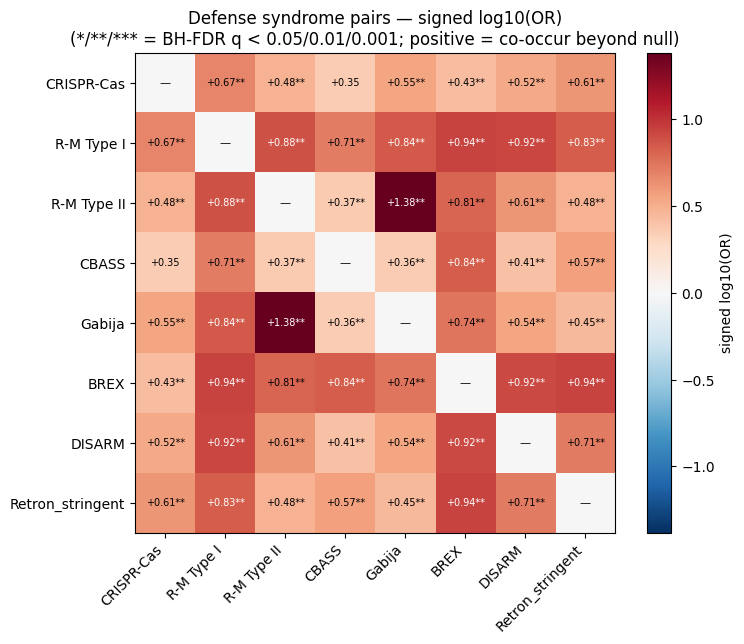

Saved: ../figures/syndrome_heatmap.png


In [6]:
or_matrix = np.zeros((len(SYSTEMS), len(SYSTEMS)))
q_matrix = np.ones((len(SYSTEMS), len(SYSTEMS)))
for _, row in obs_df.iterrows():
    i = SYSTEMS.index(row["system_A"])
    j = SYSTEMS.index(row["system_B"])
    signed = np.log10(row["odds_ratio"])
    or_matrix[i, j] = signed
    or_matrix[j, i] = signed
    q_matrix[i, j] = row["q_bh"]
    q_matrix[j, i] = row["q_bh"]

fig, ax = plt.subplots(figsize=(8, 6.5))
vmax = float(np.max(np.abs(or_matrix)))
im = ax.imshow(or_matrix, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(SYSTEMS)))
ax.set_xticklabels(SYSTEMS, rotation=45, ha="right")
ax.set_yticks(range(len(SYSTEMS)))
ax.set_yticklabels(SYSTEMS)
for i in range(len(SYSTEMS)):
    for j in range(len(SYSTEMS)):
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", fontsize=8)
            continue
        v = or_matrix[i, j]
        q = q_matrix[i, j]
        sig = "***" if q < 0.001 else "**" if q < 0.01 else "*" if q < 0.05 else ""
        color = "black" if abs(v) < 0.6 * vmax else "white"
        ax.text(j, i, f"{v:+.2f}{sig}", ha="center", va="center",
                fontsize=7, color=color)
ax.set_title("Defense syndrome pairs — signed log10(OR)\n"
             "(*/**/*** = BH-FDR q < 0.05/0.01/0.001; positive = co-occur beyond null)")
plt.colorbar(im, ax=ax, label="signed log10(OR)")
plt.tight_layout()
out_heat = os.path.join(FIG_DIR, "syndrome_heatmap.png")
plt.savefig(out_heat, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {out_heat}")

## 6. Syndrome network: positive edges at q < 0.05

Positive syndrome pairs at q<0.05: 27


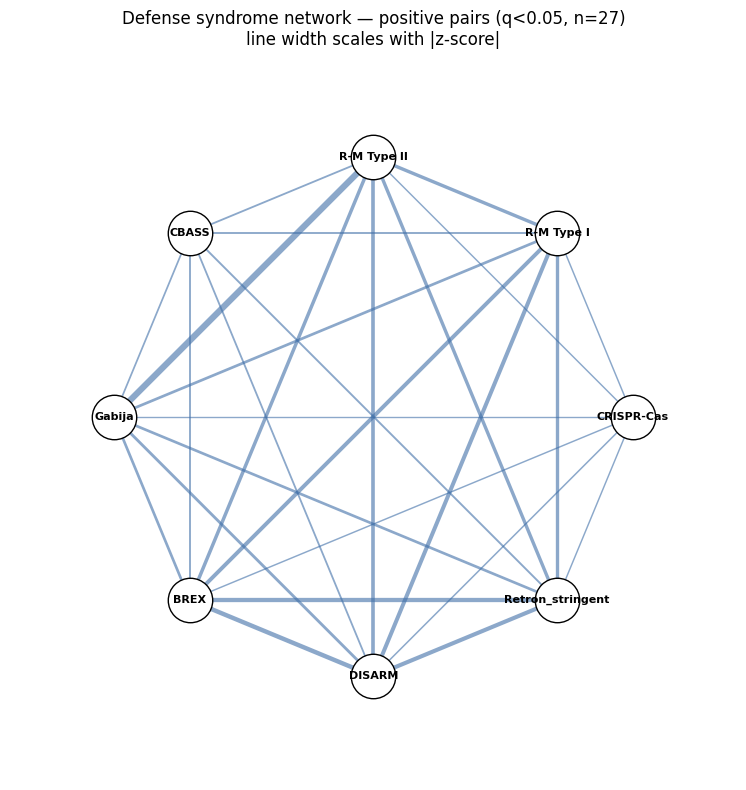

Saved: ../figures/syndrome_network.png


In [7]:
sig_pos = obs_df[(obs_df["q_bh"] < 0.05) & (obs_df["direction"] == "positive")].copy()
print(f"Positive syndrome pairs at q<0.05: {len(sig_pos)}")

# Circular layout
n = len(SYSTEMS)
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
pos = {sys: (np.cos(t), np.sin(t)) for sys, t in zip(SYSTEMS, theta)}

fig, ax = plt.subplots(figsize=(9, 8))
# Edges
max_z = sig_pos["z_score"].abs().max() if len(sig_pos) else 1.0
for _, row in sig_pos.iterrows():
    x1, y1 = pos[row["system_A"]]
    x2, y2 = pos[row["system_B"]]
    lw = 0.5 + 4 * (abs(row["z_score"]) / max_z)
    ax.plot([x1, x2], [y1, y2], "-", color="#3f6fa8", linewidth=lw, alpha=0.6)
# Nodes
for sys, (x, y) in pos.items():
    ax.plot(x, y, "o", color="white", markersize=32, markeredgecolor="black", markeredgewidth=1)
    ax.text(x, y, sys, ha="center", va="center", fontsize=8, weight="bold")
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"Defense syndrome network — positive pairs (q<0.05, n={len(sig_pos)})\n"
             f"line width scales with |z-score|")
plt.tight_layout()
out_net = os.path.join(FIG_DIR, "syndrome_network.png")
plt.savefig(out_net, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {out_net}")

## 7. Save syndrome pairs table

In [8]:
out = os.path.join(DATA_DIR, "syndrome_pairs.tsv")
obs_df_sorted.to_csv(out, sep="\t", index=False)
print(f"Wrote: {out}  ({len(obs_df_sorted)} pairs)")

Wrote: ../data/syndrome_pairs.tsv  (28 pairs)


## Summary

- 28 defense-system pairs tested against a phylum-stratified column-permutation null (N=1,000 permutations).
- Positive syndromes (co-occur beyond null, q<0.05) may reflect mobile-defense-island transfer.
- Negative pairs (co-occur less than null, q<0.05) may indicate functional redundancy or interference.

**Next**: `06_accessory_enrichment.ipynb` — test whether defense systems are enriched in the accessory pangenome (H1c).